<a href="https://colab.research.google.com/github/saranya3197/Predictive-Analytics/blob/customer-movement/customer_movement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📊 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          10 non-null     int64         
 1   CustomerID       10 non-null     object        
 2   Product          10 non-null     object        
 3   Category         10 non-null     object        
 4   Price            10 non-null     int64         
 5   Quantity         10 non-null     int64         
 6   TotalAmount      10 non-null     int64         
 7   PaymentMethod    10 non-null     object        
 8   TransactionDate  10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 852.0+ bytes
None

🧾 Dataset Preview:
   OrderID CustomerID     Product     Category  Price  Quantity  TotalAmount  \
0     1001       C001  Smartphone  Electronics  20000         1        20000   
1     1002       C002  Headphones  Electro

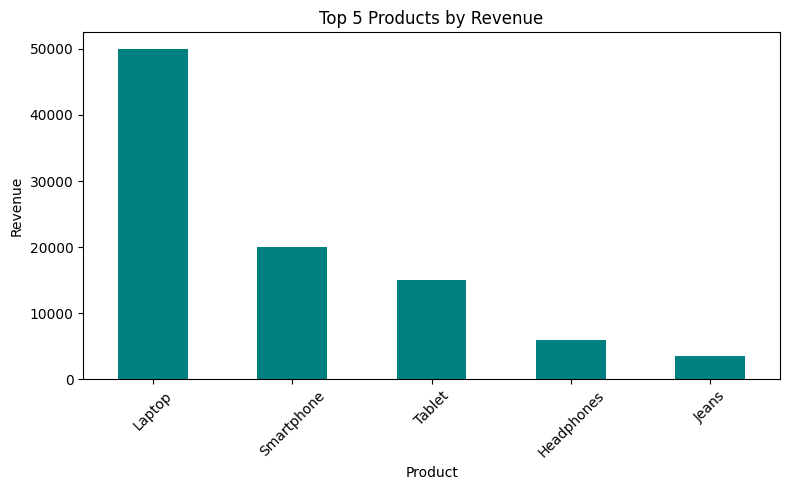


📦 Revenue by Category:
Category
Electronics    91000
Fashion         8200
Home            5000
Accessories     1000
Name: TotalAmount, dtype: int64


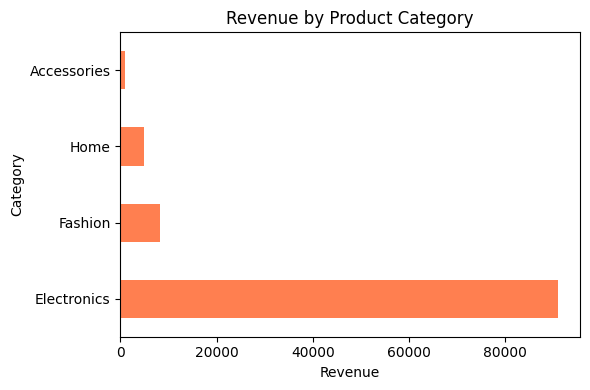


💳 Payment Method Usage:
PaymentMethod
Credit Card    3
PayPal         2
Debit Card     2
UPI            2
Cash           1
Name: count, dtype: int64


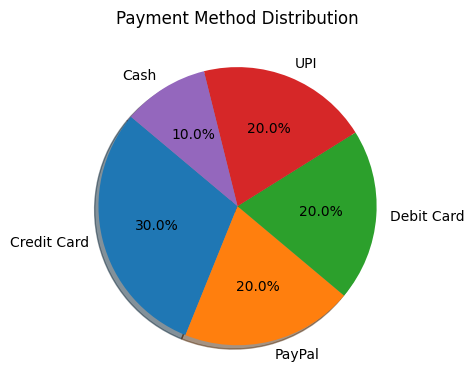

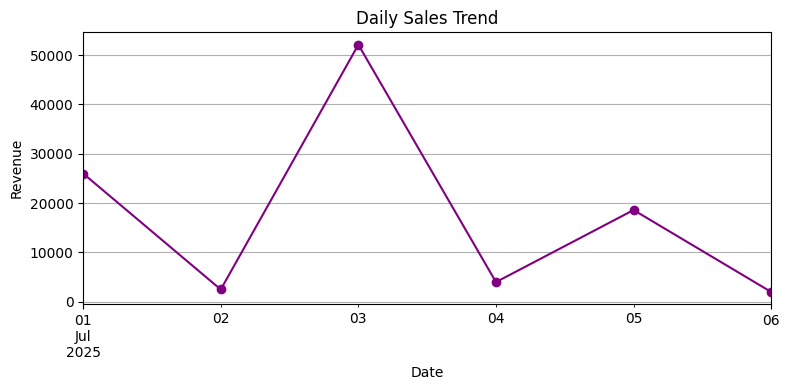

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ecommerce_money_movement_analysis.csv")

# Convert TransactionDate to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Basic Info
print("\n📊 Basic Info:")
print(df.info())

print("\n🧾 Dataset Preview:")
print(df.head())

print("\n💰 Total Revenue Generated:", df['TotalAmount'].sum())

# Top-Selling Products
top_products = df.groupby('Product')['TotalAmount'].sum().sort_values(ascending=False).head(5)
print("\n🏆 Top 5 Revenue-Generating Products:")
print(top_products)

plt.figure(figsize=(8, 5))
top_products.plot(kind='bar', color='teal')
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue by Category
revenue_by_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print("\n📦 Revenue by Category:")
print(revenue_by_category)

plt.figure(figsize=(6, 4))
revenue_by_category.plot(kind='barh', color='coral')
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Payment Method Analysis
payment_counts = df['PaymentMethod'].value_counts()
print("\n💳 Payment Method Usage:")
print(payment_counts)

plt.figure(figsize=(6, 4))
payment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Sales Trend Over Time
daily_sales = df.groupby('TransactionDate')['TotalAmount'].sum()

plt.figure(figsize=(8, 4))
daily_sales.plot(marker='o', linestyle='-', color='purple')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()
